# The value of goals

**Inspired by:** Liu, S., Ullman, T. D., Tenenbaum, J. B., & Spelke, E. S. (2017). Ten-month-old infants infer the value of goals from the costs of actions. Science, 358(6366), 1038-1041.

In [1]:
# memo, our psychology DSL
from memo import memo
import jax
import jax.numpy as np
from matplotlib import pyplot as plt

# jax2d, our physics DSL
from jax2d.engine import PhysicsEngine, create_empty_sim
from jax2d.scene import (add_circle_to_scene, add_rectangle_to_scene, add_thruster_to_scene)
from jax2d.sim_state import StaticSimParams, SimParams

In [2]:
def make_familiarization_trial():
    static_sim_params = StaticSimParams(num_circles=2, num_polygons=6, num_thrusters=2)
    engine = PhysicsEngine(static_sim_params)
    step = jax.jit(engine.step)
    sim_params = SimParams()
    sim_state = create_empty_sim(static_sim_params, add_walls_and_ceiling=True, floor_offset=0.0)
    sim_state, (_, body_idx) = add_circle_to_scene(
        sim_state, static_sim_params, position=np.array([0.1, 0.1]), radius=0.1, friction=1.0,
        velocity=np.array([0.0, 0.0]), density=1.0
    )
    ss0 = sim_state

    def setup_sim(theta, iota, wall_height):
        sim_state = ss0
        sim_state, (_, wall_idx) = add_rectangle_to_scene(
            sim_state, static_sim_params, position=np.array([1., wall_height / 2]), dimensions=np.array([0.1, wall_height]),
            fixated=True
        )
        sim_state, th_idx = add_thruster_to_scene(
            sim_state, body_idx,
            np.array([0, 0]),
            rotation=theta,
            power=iota
        )
        return sim_state

    def step_sim(t, sim_state):
        return step(
            sim_state, sim_params,
            np.array(
                [0.0] * static_sim_params.num_joints +
                [1.0 * (t == 0)] * static_sim_params.num_thrusters
            )
        )[0]

    def run_sim(theta, iota, wall_height):
        sim_state = setup_sim(theta, iota, wall_height)
        sim_state = jax.lax.fori_loop(0, 100, step_sim, sim_state)
        return sim_state.circle.position[0]

    def draw_sim(wall_height, theta, iota, color='blue'):  # for visualization only
        sim_state = setup_sim(theta, iota, wall_height)
        for t in range(100 + 1):
            sim_state = step_sim(t, sim_state)
            if t % 5 == 0:
                plt.gca().add_patch(
                    plt.Circle(sim_state.circle.position[0], sim_state.circle.radius[0], alpha=0.25, fc='red')
                )
        rect = sim_state.polygon.position[4] + sim_state.polygon.vertices[4]
        plt.plot(*(np.concatenate([rect, rect[0:1]])).T, c='k')
        plt.plot([0, 4.5], [0, 0], 'k')
        plt.plot([-0.1, -0.1], [0, 1.5], color='white')
        plt.axis('equal')
        plt.axis('off')
        plt.gca().add_patch(
            plt.Rectangle((3.5, 0), 1, 0.5, fc=color, ec='black', alpha=0.25)
        )
    return run_sim, draw_sim

run_sim, draw_sim = make_familiarization_trial()

In [3]:
def reward(goal_value, xf, yf):
    return goal_value * (xf > 2.0) * (yf < 0.5)

def utility(theta, iota, wall_height, goal_value):
    cost = iota
    r = reward(goal_value, *run_sim(theta, iota, wall_height))
    return  r - cost

LOW = 0.25, 0.75, 0.75
MED = 0.75, 1.00, 1.00
HIG = 1.25, 1.25, 1.25

Value = np.linspace(0, 2, 10)
Angle = np.linspace(0, 1.25, 6)
Impulse = np.linspace(0, 1.25, 6)
Noise = np.linspace(0.9, 1.1, 3)

from typing import no_type_check
@no_type_check
@memo(cache=True)
def agent[goal_value: Value](wall_height, theta_, iota_):
    agent: knows(goal_value)
    agent: wants(u=utility(theta * n1, iota * n2, wall_height, goal_value))
    agent: chooses(  # agent chooses action
        theta in Angle, iota in Impulse, wpp=exp(2.0 * EU[u])
    )
    agent: given(n1 in Noise, n2 in Noise, wpp=1)
    return Pr[agent.theta == theta_, agent.iota == iota_]

@no_type_check
@memo
def baby[v: Value]():
    baby: thinks[agent: given(g1_value in Value, g2_value in Value, wpp=1)]
    baby: observes_event(wpp=agent[agent.g1_value]({LOW[0]}, {LOW[1]}, {LOW[2]}))
    baby: observes_event(wpp=agent[agent.g1_value]({MED[0]}, 0, 0))
    baby: observes_event(wpp=agent[agent.g2_value]({MED[0]}, {MED[1]}, {MED[2]}))
    baby: observes_event(wpp=agent[agent.g2_value]({HIG[0]}, 0, 0))

    baby: knows(v)
    return baby[Pr[agent.g1_value == v]]
    return baby[Pr[agent.g2_value == v]]

In [4]:
def make_test_trial():
    static_sim_params = StaticSimParams(num_circles=2, num_polygons=6, num_thrusters=2)
    engine = PhysicsEngine(static_sim_params)
    step = jax.jit(engine.step)
    sim_params = SimParams()
    sim_state = create_empty_sim(static_sim_params, add_walls_and_ceiling=True, floor_offset=0.0)
    sim_state, (_, body_idx) = add_circle_to_scene(
        sim_state, static_sim_params, position=np.array([2.5, 0.1]), radius=0.1, friction=0.0,
        velocity=np.array([0.0, 0.0]), density=1.0
    )
    ss0 = sim_state

    def setup_sim(iota):
        sim_state = ss0
        sim_state, th_idx = add_thruster_to_scene(
            sim_state, body_idx,
            np.array([0, 0]),
            rotation=0,
            power=iota
        )
        return sim_state

    def step_sim(t, sim_state):
        return step(
            sim_state, sim_params,
            np.array(
                [0.0] * static_sim_params.num_joints +
                [1.0 * (t == 0)] * static_sim_params.num_thrusters
            )
        )[0]

    def run_sim(iota):
        sim_state = setup_sim(iota)
        sim_state = jax.lax.fori_loop(0, 100, step_sim, sim_state)
        return sim_state.circle.position[0]
    
    def draw_sim(iota):  # for visualization only
        sim_state = setup_sim(iota)
        for t in range(100 + 1):
            sim_state = step_sim(t, sim_state)
            if t % 5 == 0:
                plt.gca().add_patch(
                    plt.Circle(sim_state.circle.position[0], sim_state.circle.radius[0], fc='red', alpha=0.25)
                )
        rect = sim_state.polygon.position[4] + sim_state.polygon.vertices[4]
        plt.plot(*(np.concatenate([rect, rect[0:1]])).T, c='k')
        plt.plot([0, 5], [0, 0], 'k')
        plt.plot([-0.1, -0.1], [0, 1.5], color='white')
        plt.axis('equal')
        plt.axis('off')
        plt.gca().add_patch(plt.Rectangle((4, 0), 1, 0.5, fc='yellow', ec='black', alpha=0.25))
        plt.gca().add_patch(plt.Rectangle((0, 0), 1, 0.5, fc='blue', ec='black', alpha=0.25))
 
    return run_sim, draw_sim

def reward_test(g1, g2, xf, yf):
    return g1 * (xf < 1.0) + g2 * (xf > 4.0)

def utility_test(iota, g1_value, g2_value):
    cost = iota
    r = reward_test(g1_value, g2_value, *run_sim_test(iota))
    return  r - cost

run_sim_test, draw_sim_test = make_test_trial()

In [5]:
TestImpulse = np.array([-0.25, +0.25])

@no_type_check
@memo
def baby_test[iota: TestImpulse]():
    baby: thinks[agent: given(g1_value in Value, g2_value in Value, wpp=1)]
    baby: observes_event(wpp=agent[agent.g1_value]({LOW[0]}, {LOW[1]}, {LOW[2]}))
    baby: observes_event(wpp=agent[agent.g1_value]({MED[0]}, 0, 0))
    baby: observes_event(wpp=agent[agent.g2_value]({MED[0]}, {MED[1]}, {MED[2]}))
    baby: observes_event(wpp=agent[agent.g2_value]({HIG[0]}, 0, 0))
    baby: thinks[
        agent: chooses(iota in TestImpulse, wpp=exp(2.0 * utility_test(g1_value, g2_value, iota)))
    ]
    baby: knows(iota)
    return baby[Pr[agent.iota == iota]]

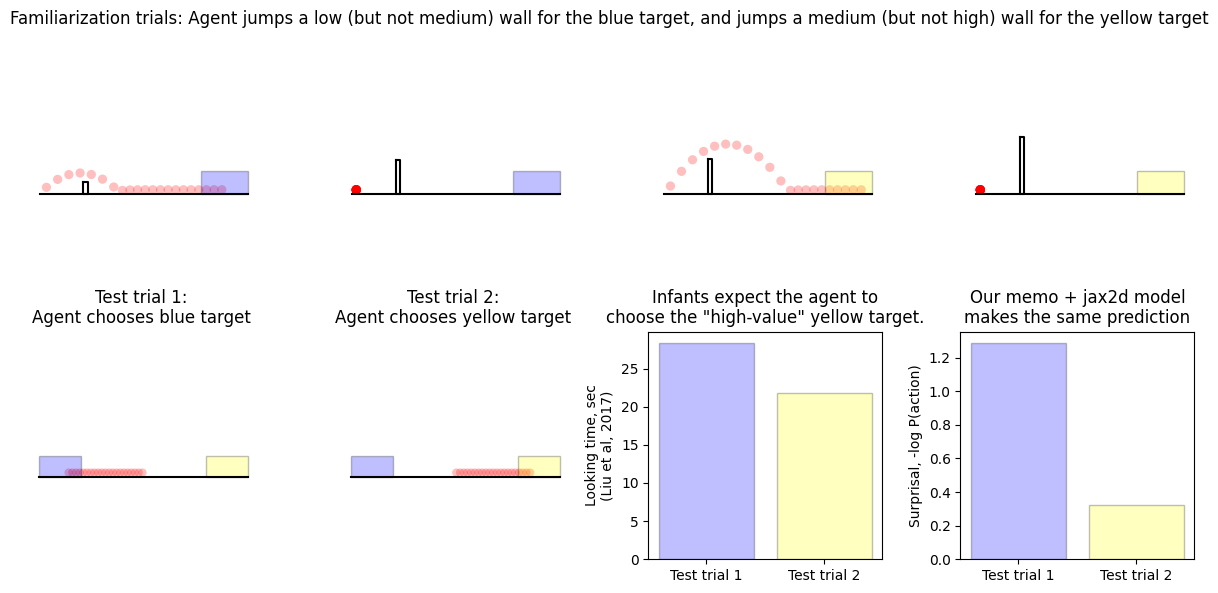

In [6]:
plt.figure(figsize=(12, 6))

LOW = 0.25, 0.75, 0.75
MED = 0.75, 1.00, 1.00
HIG = 1.25, 1.25, 1.25

plt.subplot(2, 4, 1)
draw_sim(*LOW, 'blue')

plt.subplot(2, 4, 2)
draw_sim(MED[0], 0, 0, 'blue')

plt.subplot(2, 4, 3)
draw_sim(*MED, 'yellow')

plt.subplot(2, 4, 4)
draw_sim(HIG[0], 0, 0, 'yellow')

plt.subplot(2, 4, 5)
draw_sim_test(-0.25)
plt.title('Test trial 1:\nAgent chooses blue target')

plt.subplot(2, 4, 6)
draw_sim_test(+0.25)
plt.title('Test trial 2:\nAgent chooses yellow target')

plt.subplot(2, 4, 7)
plt.bar([0, 1], [28.41, 21.79], color=['blue', 'yellow'], alpha=0.25, ec='black')
plt.ylabel('Looking time, sec\n(Liu et al, 2017)')
plt.xticks([0, 1], ["Test trial 1", "Test trial 2"])
plt.title('Infants expect the agent to\nchoose the "high-value" yellow target.')

plt.subplot(2, 4, 8)
plt.bar([0, 1], -np.log(baby_test()), color=['blue', 'yellow'], alpha=0.25, ec='black')
plt.xticks([0, 1], ["Test trial 1", "Test trial 2"])
plt.ylabel('Surprisal, -log P(action)')
plt.title('Our memo + jax2d model\nmakes the same prediction')

plt.suptitle('Familiarization trials: Agent jumps a low (but not medium) wall for the blue target, and jumps a medium (but not high) wall for the yellow target')
plt.tight_layout()
plt.savefig('twomalot-fig/sim-liu.pdf')